<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Florencia Vanella


# Consigna
En este primer trabajo práctico se diseñará y programará un generador de señales que será utilizado en las primeras simulaciones de la materia.

## Generacion de la señal
La primera tarea consiste en desarrollar una función capaz de generar una señal senoidal parametrizable, permitiendo modificar sus principales características y las condiciones de digitalización mediante un ADC.

La función deberá permitir configurar los siguientes parámetros:

- Amplitud máxima de la señal: expresada en volts (V).
- Valor medio (offset): expresado en volts (V).
- Frecuencia de la señal: expresada en hertz (Hz).
- Fase inicial: expresada en radianes (rad).
- Cantidad de muestras digitalizadas por el ADC: expresada como número de muestras.
- Frecuencia de muestreo del ADC: expresada en hertz (Hz).

A partir de estos parámetros, se deberá generar la señal senoidal y representar gráficamente tanto la señal original como las muestras obtenidas por el ADC.



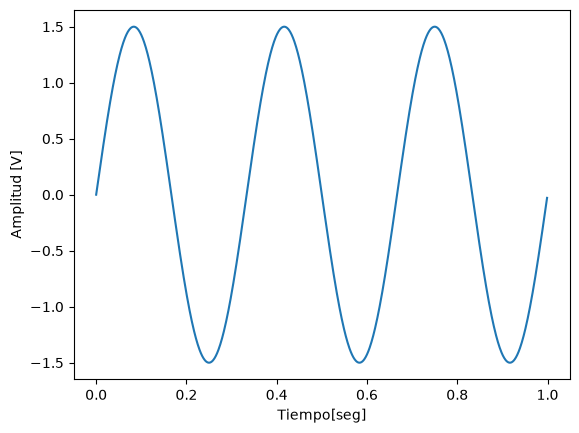

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot

# Parámetros generales
fs = 1000   # Hz - frecuencia de muestreo
N = 1000        # cantidad de muestras
ts = 1 / fs     # tiempo entre muestras

# Función para generar una señal senoidal
def mi_funcion_sen(vmax=1, dc=0, ff=3, ph=0, nn=N, fs=fs):
    
    ts = 1 / fs                     # tiempo entre cada muestra
    tt = np.arange(0, nn) * ts      # tiempo de cada muestra
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return(tt, xx)


# Comienzo de mi script
# Función de generar senoidales
vmax = 1.5      # amplitud
dc = 0          # desplazamiento vertical
ff = 3        # frecuencia variable
ph = 0          # fase
nn = N   

tt = np.arange(0, nn) * ts
xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

tt, xx = mi_funcion_sen(vmax=1.5, dc=0, ff=3, ph=0, nn=N, fs=fs)
plt.plot(tt, xx)
plt.xlabel('Tiempo[seg]')
plt.ylabel('Amplitud [V]')
plt.show()

## Experimento de muestreo

Una vez implementada la función, se deberán realizar los experimentos comentados en clase, utilizando los siguientes parámetros del ADC:

Frecuencia de muestreo: $fs = 1000 Hz$
Cantidad de muestras: $N = 1000$

Manteniendo estos valores constantes, se deberá modificar la frecuencia de la señal de entrada ($ff$) y realizar una simulación para cada uno de los siguientes casos:

$ff = 500 Hz$

$ff = 999 Hz$

$ff = 1001 Hz$

$ff = 2001 Hz$

Para cada caso se deberá representar gráficamente la señal y sus muestras, y analizar los resultados obtenidos, prestando especial atención a las diferencias entre la frecuencia de la señal y la frecuencia de muestreo.


#### Para ff= 500Hz

Como la frecuencia de muestreo es $fs=1000Hz$

La frecuencia de Nyquist es: $fN = fs/2$

Cuando la frecuencia de la señal coincide con la de frecuencia de Nyquist, la senoidal se vuelve cero. Esto se debe a que estoy tomando dos muestras por periodo, que caen siempre en los cruces por cero de la señal, por su su fase nula.


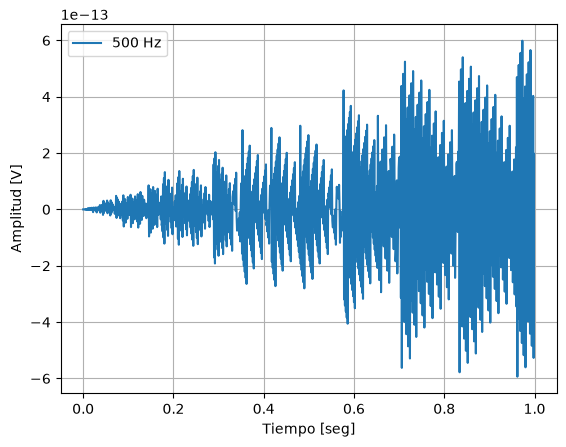

In [16]:
# 1. Primera frecuencia (f = 500 Hz)
plt.figure()
tt, xx = mi_funcion_sen(ff=500)
plt.plot(tt, xx, label="500 Hz")
plt.xlabel("Tiempo [seg]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()

Lo que se observa en el grafico es basicamente ruido numerico y la imprecision al calcular ceros teoricos. Como se aprecia la funcion oscila entre $+6*10^-13$ y $-6*10^-13$

Pero matematicamente, el valor teorico de la señal en todos los puntos de muestreo deberia ser exactamente cero.

#### Para ff=999Hz y ff=1001Hz

Ahora se evalua que pasa  $1hz$  por encima y por debajo de la frecuencia de muestreo.


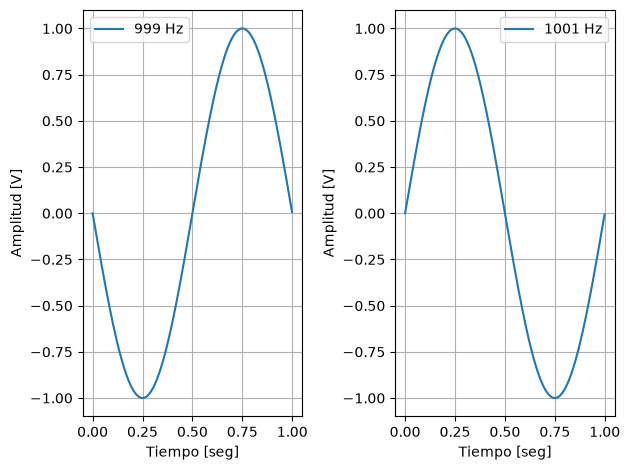

In [17]:
# 2. Segunda frecuencia (f = 999 Hz) y 3. Tercera frecuencia (f = 1001 Hz)
plt.subplot(1,2,1)
tt, xx = mi_funcion_sen(ff=999)
plt.plot(tt, xx, label="999 Hz")
plt.xlabel("Tiempo [seg]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
tt, xx = mi_funcion_sen(ff=1001)
plt.plot(tt, xx, label="1001 Hz")
plt.xlabel("Tiempo [seg]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Al desplazar la frecuencia de la señal la misma distancia hacia la derecha y hacia la izquierda de la frecuencia de muestreo, 
se observan dos señales identicas pero desfasadas 180° una respecto de la otra. 

#### Para ff=2001 Hz

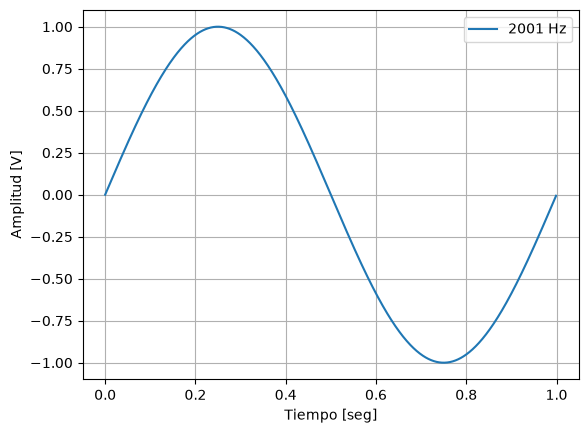

In [23]:
# 4. Cuarta frecuencia (f = 2001 Hz)
tt, xx = mi_funcion_sen(ff=2001)
plt.plot(tt, xx, label="2001 Hz")

plt.xlabel("Tiempo [seg]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()

Se obseva la misma señal que en el caso $ff=1001 Hz$ , ya que ahora estoy desplazando la frecuencia de la señal a $f + fs$ 
Esto demuestra la periodicidad espectal del muestreo de la funcion, las frecuencias que defieren de $fs$ son indistinguibles.  

## Implementar alguna otra señal propia de un generador de señales.

Se implementó una señal diente de sierra (*sawtooth*) utilizando la función *signal.sawtooth* de la biblioteca *scipy*. Para su generación se fijó una amplitud de $1\text{ V}$ (vmax = 1), una frecuencia de $3\text{ Hz}$ (ff = 3), frecuencia de muestreo de $1000\text{ Hz}$ (fs = 1000) y $1000$ muestras (N = 1000), respetando los mismos parametros utilizados en la función senoidal.

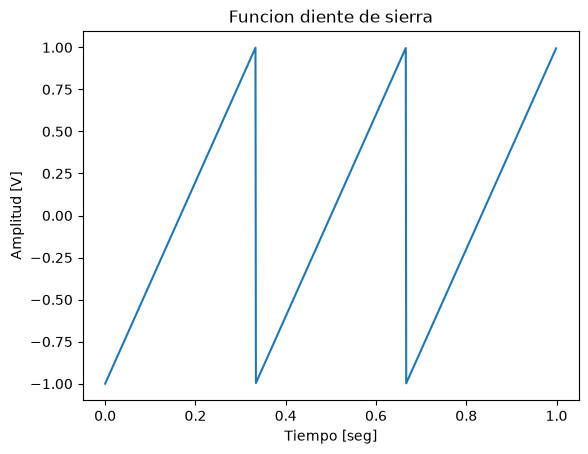

In [27]:
# Función para generar señal diente de sierra / triangular
from scipy import signal

def mi_funcion_sierra(vmax=1, dc=0, ff=3, ph=0, nn=N, fs=fs, width=1):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    # signal.sawtooth recibe la fase en radianes
    # width=1 genera diente de sierra, width=0.5 genera onda triangular
    xx2 = dc + vmax * signal.sawtooth(2 * np.pi * ff * tt + ph, width=width)
    return tt, xx2

tt, xx2 = mi_funcion_sierra(vmax=1, dc=0, ff=3, ph=0, nn=N, fs=fs, width=1)
plt.plot(tt, xx2)
plt.xlabel("Tiempo [seg]")
plt.ylabel("Amplitud [V]")
plt.title("Funcion diente de sierra")
plt.show()
